Firstly, to obtain the very first cuts of at least one muon+ with energy greater than 100GeV and accompanying muon- energy less than 10 GeV, I modify the following code. On top of that, I also apply EM energy cut

In [1]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

import os
import pandas as pd

def read_energy_and_cross_section_from_csv(directory, prefix, suffix):
    energies = []
    cross_sections = []
    
    # Iterate through all files in the directory
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            filepath = os.path.join(directory, filename)
            
            
            if os.path.isfile(filepath):
                try:
                    
                    df = pd.read_csv(filepath)
                    
                    
                    if 'Energy' in df.columns and 'Cross_section_pb' in df.columns:
                        
                        energy = df['Energy'].iloc[0]
                        cross_section = df['Cross_section_pb'].iloc[0]

                        
                        if prefix == 'hadron_events_mass_':
                            cross_section *= 1 

                        
                        energies.append(energy)
                        cross_sections.append(cross_section)
                    else:
                        print(f"Missing required columns in file: {filepath}")
                except Exception as e:
                    print(f"Error reading file {filepath}: {e}")
            else:
                print(f"File not found: {filepath}")
    
    return energies, cross_sections



def parse_events_from_df(df):
    events = []
    event = []

    for index, row in df.iterrows():
        if pd.isnull(row['pid']):
            if event:
                events.append(event)
                event = []
            continue

        pid = row['pid']
        momentum_str = row['momentum']
        parent_pids_str = row['parent_pids']

        px, py, pz, e = eval(momentum_str)
        mother1_pid, mother2_pid = eval(parent_pids_str)

        event.append((pid, px, py, pz, e, mother1_pid, mother2_pid))

    if event:
        events.append(event)

    return events
###Logic for counting muon events- cuts applied on muon+ energy and muon- energy
def count_muon_events_csv(directory, muon_plus_threshold, prefix, suffix):
    EM_energy_sums = defaultdict(lambda: defaultdict(list))

    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            parts = filename[len(prefix):-len(suffix)].split('_')
            energy = float(parts[-1])  

            filepath = os.path.join(directory, filename)
            
            df = pd.read_csv(filepath)

            
            events = parse_events_from_df(df)

            excluded_pids = [11, 22, -11]

            
            for event in events:                   
                muon_plus_found = False
                muon_minus_high_energy_found = False
                EM_energy_sum = 0

                for pid, px, py, pz, e, _, _ in event:
                    if pid == -13 and e > muon_plus_threshold:
                        muon_plus_found = True
                    elif pid == 13 and e > 10:
                        muon_minus_high_energy_found = True
                    elif pid in excluded_pids:
                        EM_energy_sum += e

                if muon_plus_found and not muon_minus_high_energy_found:

                    EM_energy_sums[energy]['EM_energy_sum'].append(EM_energy_sum)

    return EM_energy_sums

####Extra cut applied on EM energy
def apply_cut(EM_energy_sums, weights, energy_cut):
    EM_energy_sums = np.array(EM_energy_sums)
    pass_cut = EM_energy_sums < energy_cut  
    return np.array(weights)[pass_cut]

def calculate_significance(S, B):
    if B == 0:
        return np.inf  
    return S / np.sqrt(B)




Processing dataset: NC_nue
Processing dataset: CC_nue
Processing dataset: CC_numu
Processing dataset: NC_numu
Processing dataset: signal_1
Processing dataset: signal_2
coupling(m_phi = 20 GeV): 4.25e+00
coupling(m_phi = 0.125 GeV): 5.88e-03
CC_nue events before cut: 4.36e+00
CC_numu events before cut: 1.93e+03
NC_nue events before cut: 2.65e+02
NC_numu events before cut: 1.66e+03


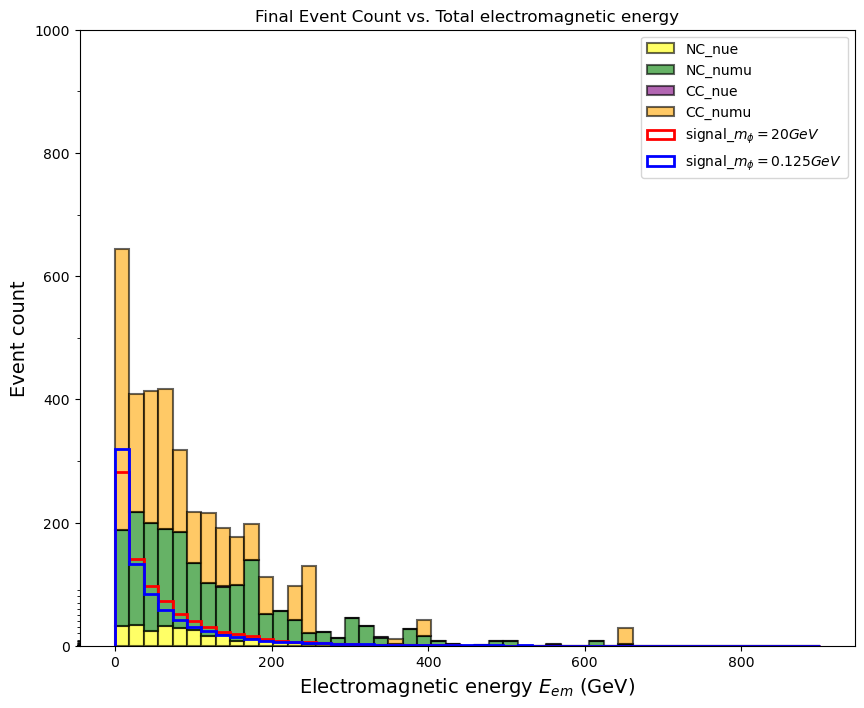

CC_nue events after cut: 2.12e+00
CC_numu events after cut: 1.71e+03
NC_nue events after cut: 2.37e+02
NC_numu events after cut: 1.36e+03
820.9999999997519
780.0000000004702
3859.234037761282
Signal 1 (m_phi = 20 GeV) before cut: 8.21e+02
Signal 2 (m_phi = 0.125 GeV) before cut: 7.80e+02
Background before cut: 3.86e+03
Signal 1 (m_phi = 20 GeV) after cut: 7.81e+02
Signal 2 (m_phi = 0.125 GeV) after cut: 7.40e+02
Background after cut: 3.30e+03
Significance for signal 1 (m_phi = 20 GeV) after cut: 13.60
Significance for signal 2 (m_phi = 0.125 GeV) after cut: 12.87


In [2]:
##Processing to get weight of signal 
def main():
    datasets = {
        'NC_nue': ('angle_NC_nue', 'events_', '_GeV.csv'),
        'CC_nue': ('angle_CC_nue', 'events_', '_GeV.csv'),
        'CC_numu': ('angle_CC_numu', 'events_', '_GeV.csv'),
        'NC_numu': ('angle_NC_numu', 'events_', '_GeV.csv'),
        'signal_1': ('Hadron_events_output', 'hadron_events_mass_', '.csv'),
        'signal_2': ('Hadron_events_output/mass = 0.125', 'hadron_events_mass_', '.csv')
    }

    scaling_factor = 1.9060455065868266e-11
    ###Flux of incoming neutrinos
    file1 = "MC_-14_3TeV_with_cut_with_z.txt"
    column_names_df1 = ["x", "y","z"]
    df1 = pd.read_csv(file1, delim_whitespace=True, names=column_names_df1)
    energy_events = df1["x"]
    events_per_year = df1["y"] * 3 * 10**7
    events_per_year_nue = df1["z"] * 3 * 10**7

    all_final_events = defaultdict(lambda: defaultdict(list))

    muon_plus_thresholds = [100]
    colors = {
        'NC_nue': ['yellow'],
        'CC_nue': ['purple'],
        'CC_numu': ['orange'],
        'NC_numu': ['green'],
        'signal_1': ['red'],
        'signal_2': ['blue']
    }

    plt.figure(figsize=(10, 8))

    bins = np.linspace(0,900, 50)  

    stacked_data = defaultdict(list)
    signal_1_energy_sums = []
    signal_1_weights = []
    signal_2_energy_sums = []
    signal_2_weights = []

    total_signal_1_events = 0
    total_signal_2_events = 0

    for dataset_name, (directory, prefix, suffix) in datasets.items():
        print(f"Processing dataset: {dataset_name}")
#         filepath = f"/Users/adhikaryj/ECN3Plot/Background/{directory}/"
        energies, cross_sections = read_energy_and_cross_section_from_csv(directory,prefix,suffix)
        cross_section_dict = dict(zip(energies, cross_sections))

        for threshold, color in zip(muon_plus_thresholds, colors[dataset_name]):
            condition_label = f'muon+_gt_{threshold}GeV'
            
            group_counts_with_veto = count_muon_events_csv(directory, muon_plus_threshold=threshold, prefix=prefix, suffix=suffix)
            
            for energy, energy_data in group_counts_with_veto.items():
                if dataset_name in ['CC_nue', 'NC_nue']:
                    events_rate = events_per_year_nue[energy_events == energy].values
                else:
                    events_rate = events_per_year[energy_events == energy].values
                
                cross_section = cross_section_dict.get(energy, None)
                for EM_energy_sum in energy_data['EM_energy_sum']:
                    if dataset_name in ['CC_nue', 'NC_nue']:
                        if energy > 800:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10*10**6))
                        else:
                            scaled_event_rate = events_rate[0] * cross_section * scaling_factor / 10**6
                            
                    elif dataset_name == 'NC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.55**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    
                    elif dataset_name == 'CC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    elif dataset_name == 'signal_1':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor) / 10**4
                        total_signal_1_events += scaled_event_rate
                    elif dataset_name == 'signal_2':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor) / 10**4
                        total_signal_2_events += scaled_event_rate

                    all_final_events[dataset_name][condition_label].append((EM_energy_sum, scaled_event_rate))

            energy_sums = []
            weights = []

            if condition_label in all_final_events[dataset_name]:
                for EM_energy_sum, weight in all_final_events[dataset_name][condition_label]:
                    energy_sums.append(EM_energy_sum)
                    weights.append(weight)

                if dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
                    stacked_data[dataset_name].append((energy_sums, weights))
                elif dataset_name == 'signal_1':
                     signal_1_energy_sums.extend(energy_sums)
                     signal_1_weights.extend(weights)
                elif dataset_name == 'signal_2':
                     signal_2_energy_sums.extend(energy_sums)
                     signal_2_weights.extend(weights)
    


    if total_signal_1_events > 0:
        scaling_factor_signal_1 = 821 / total_signal_1_events
        print(f"coupling(m_phi = 20 GeV): {scaling_factor_signal_1:.2e}")
        
        signal_1_weights = [w * scaling_factor_signal_1 for w in signal_1_weights]

    if total_signal_2_events > 0:
        scaling_factor_signal_2 = 780 / total_signal_2_events
        print(f"coupling(m_phi = 0.125 GeV): {scaling_factor_signal_2:.2e}")
        signal_2_weights = [w * scaling_factor_signal_2 for w in signal_2_weights]


    
    ratio_signal_1_to_background = []
    ratio_signal_2_to_background = []

    
    background_muon_energies = []
    background_weights = []
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        for muon_energies, weights in stacked_data[dataset_name]:
            background_muon_energies.extend(muon_energies)
            background_weights.extend(weights)
    
    background_total_weights, _ = np.histogram(background_muon_energies, 
                                               bins=bins, 
                                               weights=background_weights)
    
    signal_1_hist_weights, _ = np.histogram(signal_1_energy_sums, bins=bins, weights=signal_1_weights)
    signal_2_hist_weights, _ = np.histogram(signal_2_energy_sums, bins=bins, weights=signal_2_weights)
    background_event_counts_before_cut = {}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        total_weight_before_cut = sum([np.sum(weights) for _, weights in stacked_data[dataset_name]])
        background_event_counts_before_cut[dataset_name] = total_weight_before_cut
        print(f"{dataset_name} events before cut: {total_weight_before_cut:.2e}")
        
    for bkg, sig1, sig2 in zip(background_total_weights, signal_1_hist_weights, signal_2_hist_weights):
        ratio_signal_1_to_background.append(sig1 / bkg if bkg > 0 else 0)
        ratio_signal_2_to_background.append(sig2 / bkg if bkg > 0 else 0)

    plt.hist([energy_sums for energy_sums, _ in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             bins=bins,
             weights=[weights for _, weights in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             histtype="barstacked", alpha=0.6, stacked=True, edgecolor='black', linewidth=1.5,
             label=['NC_nue','NC_numu', 'CC_nue','CC_numu'], color=['yellow','green', 'purple','orange'])

    plt.hist(signal_1_energy_sums, bins=bins, weights=signal_1_weights, histtype="step", color='red', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=20GeV$')
    plt.hist(signal_2_energy_sums, bins=bins, weights=signal_2_weights, histtype="step", color='blue', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=0.125GeV$')

    # Plot the ratio of signal to background
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     plt.plot(bin_centers, ratio_signal_1_to_background, 'r--',marker='.', label=r'Ratio to BG: $m_{\phi}=20GeV$')
#     plt.plot(bin_centers, ratio_signal_2_to_background, 'b--',marker='.', label=r'Ratio to BG: $m_{\phi}=0.125GeV$')
    

    plt.xlabel(r'Electromagnetic energy $E_{em}$ (GeV)', fontsize=14)
    plt.ylabel('Event count', fontsize=14)
    plt.title(r'Final Event Count vs. Total electromagnetic energy')
    #plt.yscale('log')
    plt.ylim(0, 10**3)
    plt.gca().yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs='auto'))
    plt.legend(loc='upper right')
    
    plt.show()
    energy_cut_value = 200 

    signal_1_weights_after_cut = apply_cut(signal_1_energy_sums, signal_1_weights, energy_cut_value)
    signal_2_weights_after_cut = apply_cut(signal_2_energy_sums, signal_2_weights, energy_cut_value)
    background_weights_after_cut = apply_cut(background_muon_energies, background_weights, energy_cut_value)
    background_event_counts_after_cut={}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        pt_sums_after_cut = []
        weights_after_cut = []
        for pt_sums, weights in stacked_data[dataset_name]:
            filtered_weights = apply_cut(pt_sums, weights, energy_cut_value)
            pt_sums_after_cut.extend(pt_sums)
            weights_after_cut.extend(filtered_weights)
    
        total_weight_after_cut = np.sum(weights_after_cut)
        background_event_counts_after_cut[dataset_name] = total_weight_after_cut
        print(f"{dataset_name} events after cut: {total_weight_after_cut:.2e}")
    
    S_signal_1 = np.sum(signal_1_weights_after_cut)
    S_signal_2 = np.sum(signal_2_weights_after_cut)
    B_background = np.sum(background_weights_after_cut)
    total_signal_1_before_cut = np.sum(signal_1_weights)
    print(total_signal_1_before_cut)
    total_signal_2_before_cut = np.sum(signal_2_weights)
    print(total_signal_2_before_cut)
    total_background_before_cut = np.sum(background_weights)
    print(total_background_before_cut)


    
    significance_signal_1 = calculate_significance(S_signal_1, B_background)
    significance_signal_2 = calculate_significance(S_signal_2, B_background)

    print(f"Signal 1 (m_phi = 20 GeV) before cut: {total_signal_1_before_cut:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) before cut: {total_signal_2_before_cut:.2e}")
    print(f"Background before cut: {total_background_before_cut:.2e}")
    print(f"Signal 1 (m_phi = 20 GeV) after cut: {S_signal_1:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) after cut: {S_signal_2:.2e}")
    print(f"Background after cut: {B_background:.2e}")
    print(f"Significance for signal 1 (m_phi = 20 GeV) after cut: {significance_signal_1:.2f}")
    print(f"Significance for signal 2 (m_phi = 0.125 GeV) after cut: {significance_signal_2:.2f}")
    

if __name__ == '__main__':
    main()


Again, I am supposed to now put the CHARM veto. It is divided into two parts, full veto and 80% veto. For this, I just accomodate it in the count muon function

Processing dataset: NC_nue
Processing dataset: CC_nue
Processing dataset: CC_numu
Processing dataset: NC_numu
Processing dataset: signal_1
Processing dataset: signal_2
CC_nue events before cut: 2.12e+00
CC_numu events before cut: 0.00e+00
NC_nue events before cut: 1.55e+00
NC_numu events before cut: 3.56e+00


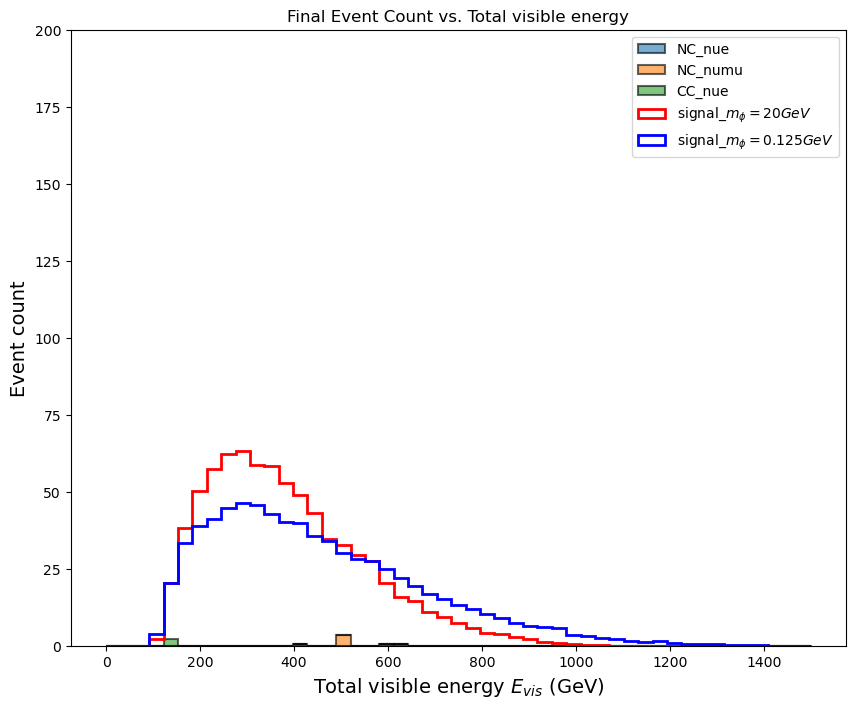

CC_nue events after cut: 2.12e+00
CC_numu events after cut: 0.00e+00
NC_nue events after cut: 6.64e-01
NC_numu events after cut: 3.56e+00
Signal 1 (m_phi = 20 GeV) before cut: 7.80e+02
Signal 2 (m_phi = 0.125 GeV) before cut: 7.40e+02
Background before cut: 7.23e+00
Signal 1 (m_phi = 20 GeV) after cut: 6.01e+02
Signal 2 (m_phi = 0.125 GeV) after cut: 4.77e+02
Background after cut: 6.34e+00
Significance for signal 1 (m_phi = 20 GeV) after cut: 238.53
Significance for signal 2 (m_phi = 0.125 GeV) after cut: 189.56


In [1]:
###Next check for visible energy with EM energy cut plus mu+ threshold already present 
##Pecentage of cut should be calculated wrt the initial number of particles without any cut
####Plot for visible energy

import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

import os
import pandas as pd

def read_energy_and_cross_section(directory, prefix, suffix):
    energies = []
    cross_sections = []
    
    
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            filepath = os.path.join(directory, filename)
            
            
            if os.path.isfile(filepath):
                try:
                    
                    df = pd.read_csv(filepath)
                    
                    
                    if 'Energy' in df.columns and 'Cross_section_pb' in df.columns:
                        
                        energy = df['Energy'].iloc[0]
                        cross_section = df['Cross_section_pb'].iloc[0]

                        
                        if prefix == 'hadron_events_mass_':
                            cross_section *= 1  

                        
                        energies.append(energy)
                        cross_sections.append(cross_section)
                    else:
                        print(f"Missing required columns in file: {filepath}")
                except Exception as e:
                    print(f"Error reading file {filepath}: {e}")
            else:
                print(f"File not found: {filepath}")
    
    return energies, cross_sections



def parse_events_from_df(df):
    events = []
    event = []

    for index, row in df.iterrows():
        if pd.isnull(row['pid']):
            if event:
                events.append(event)
                event = []
            continue

        pid = row['pid']
        momentum_str = row['momentum']
        parent_pids_str = row['parent_pids']

        px, py, pz, e = eval(momentum_str)
        mother1_pid, mother2_pid = eval(parent_pids_str)

        event.append((pid, px, py, pz, e, mother1_pid, mother2_pid))

    if event:
        events.append(event)

    return events




# def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
#     #EM_energy_sums = defaultdict(lambda: defaultdict(list))
#     visible_energy_sums = defaultdict(lambda: defaultdict(list)) 
#     for filename in os.listdir(directory):
#         if filename.startswith(prefix) and filename.endswith(suffix):
#             parts = filename[len(prefix):-len(suffix)].split('_')
#             energy = float(parts[-1])  

#             filepath = os.path.join(directory, filename)
            
            
#             df = pd.read_csv(filepath)

           
#             events = parse_events_from_df(df)
#             pid_inv = [12, -12, 14, -14, 16, -16,39]
#             excluded_pids = [11, 22, -11]
                       
#             for event in events:                    
#                 muon_plus_found = False
#                 muon_minus_high_energy_found = False
#                 EM_energy_sum = 0
#                 visible_energy_sum=0
#                 charm_meson_parent_found = False

#                 for pid, px, py, pz, e, parent_pid, _ in event:
#                     if pid==-13 and parent_pid in [411, -411, 421, -421, 431, -431,4,4122,-4122,15,-15,521,-521,511,-511,531,-531,443,-443,5122,-5122,4232,-4232,4112,-4112,5232,-5232]:  
#                         charm_meson_parent_found = True
                        
                    
#                     elif pid == -13 and e > muon_plus_threshold:  
#                         muon_plus_found = True
#                         visible_energy_sum += e

#                     elif pid == 13 and e > 10:  
#                          muon_minus_high_energy_found = True
                        
#                     elif pid in excluded_pids:  
#                          EM_energy_sum += e  
                        
#                     elif pid not in pid_inv:  
#                          visible_energy_sum += e  
                
                

#                 if muon_plus_found:
#                     if EM_energy_sum > 200:
#                         continue
                        
#                 if muon_plus_found:
#                     if charm_meson_parent_found:
#                         continue
                    
# #                 if muon_plus_found:
# #                     if visible_energy_sum >500:
# #                         continue
                
                
#                 if muon_plus_found and not muon_minus_high_energy_found: 
#                    visible_energy_sums[energy]['visible_energy_sum'].append(visible_energy_sum)  # Append energy sum for this event

#     return visible_energy_sums

def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
    # Dictionary to store sums of visible energy for each energy value
    visible_energy_sums = defaultdict(lambda: defaultdict(list))
    
    # Define the invariant and excluded particle IDs
    pid_inv = [12, -12, 14, -14, 16, -16, 39]  # Neutrinos and other invisible particles
    excluded_pids = [11, 22, -11]  # Electron, positron, photon
    
    # Define the list of PIDs considered as charm meson parents
    charm_meson_pids = [411, -411, 421, -421, 431, -431, 4, 4122, -4122, 
                        15, -15, 521, -521, 511, -511, 531, -531, 443, -443, 
                        5122, -5122, 4232, -4232, 4112, -4112, 5232, -5232]

    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            # Extract the energy from the filename
            parts = filename[len(prefix):-len(suffix)].split('_')
            energy = float(parts[-1])  # Extract the energy value from the filename
            
            # Read the CSV file into a DataFrame
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            
            # Parse events from DataFrame
            events = parse_events_from_df(df)
            
            for event in events:                    
                muon_plus_found = False
                muon_minus_high_energy_found = False
                EM_energy_sum = 0
                visible_energy_sum = 0
                muon_plus_parent_pid = None  # Track the parent PID of muon+

                # Loop through particles in the event
                for pid, px, py, pz, e, parent_pid, _ in event:
                    if pid == -13 and e > muon_plus_threshold:  # Muon+ found
                        muon_plus_found = True
                        visible_energy_sum += e
                        muon_plus_parent_pid = parent_pid  # Record the parent PID of muon+
                    
                    elif pid == 13 and e > 10:  # Muon- with high energy found
                        muon_minus_high_energy_found = True
                        
                    elif pid in excluded_pids:  # Sum electromagnetic energy
                        EM_energy_sum += e
                        
                    elif pid not in pid_inv:  # Sum visible energy for all other particles
                        visible_energy_sum += e
                
                # Apply veto for high electromagnetic energy sum (> 200)
                if muon_plus_found:
                    if EM_energy_sum > 200:
                        continue

                # Apply cuts if muon+ is found and no high-energy muon- is present
                if muon_plus_found and not muon_minus_high_energy_found:
                    if muon_plus_parent_pid in charm_meson_pids:
                          continue
                    else: 
                    # Append the visible energy and weight modifier to the dictionary
                         visible_energy_sums[energy]['visible_energy_sum'].append((visible_energy_sum))

    return visible_energy_sums
def apply_cut(visible_energy_sums, weights, visible_cut):
    """
    Apply a cut on pt_sums and return the weights of events that pass the cut.
    
    Parameters:
    pt_sums: np.array - the array of transverse momentum sums for events
    weights: np.array - the weights corresponding to the events
    pt_cut: float - the cut threshold for pT

    Returns:
    np.array - the weights of events that pass the cut
    """
    visible_energy_sums = np.array(visible_energy_sums)
    pass_cut = visible_energy_sums < visible_cut
    return np.array(weights)[pass_cut]

def calculate_significance(S, B):
    """
    Calculate the sensitivity (S/sqrt(B)).
    
    Parameters:
    S: float - total signal events
    B: float - total background events

    Returns:
    float - the significance S/sqrt(B)
    """
    if B == 0:
        return np.inf  
    return S / np.sqrt(B)

def main():
    datasets = {
        'NC_nue': ('angle_NC_nue', 'events_', '_GeV.csv'),
        'CC_nue': ('angle_CC_nue', 'events_', '_GeV.csv'),
        'CC_numu': ('angle_CC_numu', 'events_', '_GeV.csv'),
        'NC_numu': ('angle_NC_numu', 'events_', '_GeV.csv'),
        'signal_1': ('Hadron_events_output', 'hadron_events_mass_', '.csv'),
        'signal_2': ('Hadron_events_output/mass = 0.125', 'hadron_events_mass_', '.csv')
    }

    scaling_factor = 1.9060455065868266e-11
    ###Flux of incoming neutrinos
    file1 = "MC_-14_3TeV_with_cut_with_z.txt"
    column_names_df1 = ["x", "y","z"]
    df1 = pd.read_csv(file1, delim_whitespace=True, names=column_names_df1)
    energy_events = df1["x"]
    events_per_year = df1["y"] * 3 * 10**7
    events_per_year_nue = df1["z"] * 3 * 10**7

    all_final_events = defaultdict(lambda: defaultdict(list))

    muon_plus_thresholds = [100]
    colors = {
        'NC_nue': ['yellow'],
        'CC_nue': ['purple'],
        'CC_numu': ['orange'],
        'NC_numu': ['green'],
        'signal_1': ['red'],
        'signal_2': ['blue']
    }

    plt.figure(figsize=(10, 8))

    bins = np.linspace(0,1500, 50)  

    stacked_data = defaultdict(list)
    signal_1_energy_sums = []
    signal_1_weights = []
    signal_2_energy_sums = []
    signal_2_weights = []

    total_signal_1_events = 0
    total_signal_2_events = 0

    for dataset_name, (directory, prefix, suffix) in datasets.items():
        print(f"Processing dataset: {dataset_name}")

        energies, cross_sections = read_energy_and_cross_section(directory, prefix, suffix)
        cross_section_dict = dict(zip(energies, cross_sections))

        for threshold, color in zip(muon_plus_thresholds, colors[dataset_name]):
            condition_label = f'muon+_gt_{threshold}GeV'
            
            group_counts_with_veto = count_muon_events(directory, muon_plus_threshold=threshold, prefix=prefix, suffix=suffix)

            for energy, energy_data in group_counts_with_veto.items():
                if dataset_name in ['CC_nue', 'NC_nue']:
                    events_rate = events_per_year_nue[energy_events == energy].values
                else:
                    events_rate = events_per_year[energy_events == energy].values
                
                cross_section = cross_section_dict.get(energy, None)
                for visible_energy_sum in energy_data['visible_energy_sum']:
                    
                        
                    if dataset_name in ['CC_nue', 'NC_nue']:
                        if energy > 800:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10*10**6))
                        else:
                            scaled_event_rate = events_rate[0] * cross_section * scaling_factor / 10**6
                            
                    elif dataset_name == 'NC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.55**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    
                    elif dataset_name == 'CC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    elif dataset_name == 'signal_1':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor) / 10**4
                        total_signal_1_events += scaled_event_rate
                    elif dataset_name == 'signal_2':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor) / 10**4
                        total_signal_2_events += scaled_event_rate

                    


                    all_final_events[dataset_name][condition_label].append((visible_energy_sum, scaled_event_rate))

            energy_sums = []
            weights = []

            if condition_label in all_final_events[dataset_name]:
                for visible_energy_sum, weight in all_final_events[dataset_name][condition_label]:
                    energy_sums.append(visible_energy_sum)
                    weights.append(weight)

                if dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
                    stacked_data[dataset_name].append((energy_sums, weights))
                elif dataset_name == 'signal_1':
                     signal_1_energy_sums.extend(energy_sums)
                     signal_1_weights.extend(weights)
                elif dataset_name == 'signal_2':
                     signal_2_energy_sums.extend(energy_sums)
                     signal_2_weights.extend(weights)

  

    #Rescaling of signal is done after putting previous cuts which in this case is muon-, muon+ energy, em energy and charm veto                 
 
    if total_signal_1_events > 0:
        scaling_factor_signal_1 = 780/ total_signal_1_events
        #print(scaling_factor_signal_1)
        signal_1_weights = [w * scaling_factor_signal_1 for w in signal_1_weights]

    if total_signal_2_events > 0:
        scaling_factor_signal_2 = 740/ total_signal_2_events
        #print(scaling_factor_signal_2)
        signal_2_weights = [w * scaling_factor_signal_2 for w in signal_2_weights]


    # Calculate the ratio of signal to background in each bin
    ratio_signal_1_to_background = []
    ratio_signal_2_to_background = []

    # Concatenate all muon energies and weights for background datasets
    background_muon_energies = []
    background_weights = []
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        for muon_energies, weights in stacked_data[dataset_name]:
            background_muon_energies.extend(muon_energies)
            background_weights.extend(weights)
    
    background_total_weights, _ = np.histogram(background_muon_energies, 
                                               bins=bins, 
                                               weights=background_weights)
    
    signal_1_hist_weights, _ = np.histogram(signal_1_energy_sums, bins=bins, weights=signal_1_weights)
    signal_2_hist_weights, _ = np.histogram(signal_2_energy_sums, bins=bins, weights=signal_2_weights)
    background_event_counts_before_cut = {}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        total_weight_before_cut = sum([np.sum(weights) for _, weights in stacked_data[dataset_name]])
        background_event_counts_before_cut[dataset_name] = total_weight_before_cut
        print(f"{dataset_name} events before cut: {total_weight_before_cut:.2e}")
        
    for bkg, sig1, sig2 in zip(background_total_weights, signal_1_hist_weights, signal_2_hist_weights):
        ratio_signal_1_to_background.append(sig1 / bkg if bkg > 0 else 0)
        ratio_signal_2_to_background.append(sig2 / bkg if bkg > 0 else 0)

    plt.hist([energy_sums for energy_sums, _ in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             bins=bins,
             weights=[weights for _, weights in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             histtype="barstacked", alpha=0.6, stacked=True, edgecolor='black', linewidth=1.5,
             label=['NC_nue','NC_numu', 'CC_nue','CC_numu'])#, color=['yellow','green', 'purple','orange'])

    plt.hist(signal_1_energy_sums, bins=bins, weights=signal_1_weights, histtype="step", color='red', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=20GeV$')
    plt.hist(signal_2_energy_sums, bins=bins, weights=signal_2_weights, histtype="step", color='blue', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=0.125GeV$')

    # Plot the ratio of signal to background
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     plt.plot(bin_centers, ratio_signal_1_to_background, 'r--',marker='.', label=r'Ratio to BG: $m_{\phi}=20GeV$')
#     plt.plot(bin_centers, ratio_signal_2_to_background, 'b--',marker='.', label=r'Ratio to BG: $m_{\phi}=0.125GeV$')

    plt.xlabel(r'Total visible energy $E_{vis}$ (GeV)', fontsize=14)
    plt.ylabel('Event count', fontsize=14)
    plt.title(r'Final Event Count vs. Total visible energy')
    #plt.yscale('log')
    plt.ylim(0, 200)
    ax = plt.gca()  # Get current axes
    #formatter = mticker.ScalarFormatter(useMathText=True)
    #formatter.set_powerlimits((6, 7))  
    #ax.yaxis.set_major_formatter(formatter)
    plt.legend(loc='upper right')
    
    plt.show()
    
    visible_cut_value = 500 

    signal_1_weights_after_cut = apply_cut(signal_1_energy_sums, signal_1_weights, visible_cut_value)
    signal_2_weights_after_cut = apply_cut(signal_2_energy_sums, signal_2_weights, visible_cut_value)
    background_weights_after_cut = apply_cut(background_muon_energies, background_weights, visible_cut_value)
    background_event_counts_after_cut={}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        pt_sums_after_cut = []
        weights_after_cut = []
        for pt_sums, weights in stacked_data[dataset_name]:
            filtered_weights = apply_cut(pt_sums, weights, visible_cut_value)
            pt_sums_after_cut.extend(pt_sums)
            weights_after_cut.extend(filtered_weights)
    
        total_weight_after_cut = np.sum(weights_after_cut)
        background_event_counts_after_cut[dataset_name] = total_weight_after_cut
        print(f"{dataset_name} events after cut: {total_weight_after_cut:.2e}")
    
    S_signal_1 = np.sum(signal_1_weights_after_cut)
    S_signal_2 = np.sum(signal_2_weights_after_cut)
    B_background = np.sum(background_weights_after_cut)
    total_signal_1_before_cut = np.sum(signal_1_weights)
    total_signal_2_before_cut = np.sum(signal_2_weights)
    total_background_before_cut = np.sum(background_weights)


    
    
    significance_signal_1 = calculate_significance(S_signal_1, B_background)
    significance_signal_2 = calculate_significance(S_signal_2, B_background)
    print(f"Signal 1 (m_phi = 20 GeV) before cut: {total_signal_1_before_cut:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) before cut: {total_signal_2_before_cut:.2e}")
    print(f"Background before cut: {total_background_before_cut:.2e}")
    print(f"Signal 1 (m_phi = 20 GeV) after cut: {S_signal_1:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) after cut: {S_signal_2:.2e}")
    print(f"Background after cut: {B_background:.2e}")
    print(f"Significance for signal 1 (m_phi = 20 GeV) after cut: {significance_signal_1:.2f}")
    print(f"Significance for signal 2 (m_phi = 0.125 GeV) after cut: {significance_signal_2:.2f}")
    


if __name__ == '__main__':
    main()



Processing dataset: NC_nue
Processing dataset: CC_nue
Processing dataset: CC_numu
Processing dataset: NC_numu
Processing dataset: signal_1
Processing dataset: signal_2
CC_nue events before cut: 2.12e+00
CC_numu events before cut: 3.41e+02
NC_nue events before cut: 4.86e+01
NC_numu events before cut: 2.74e+02


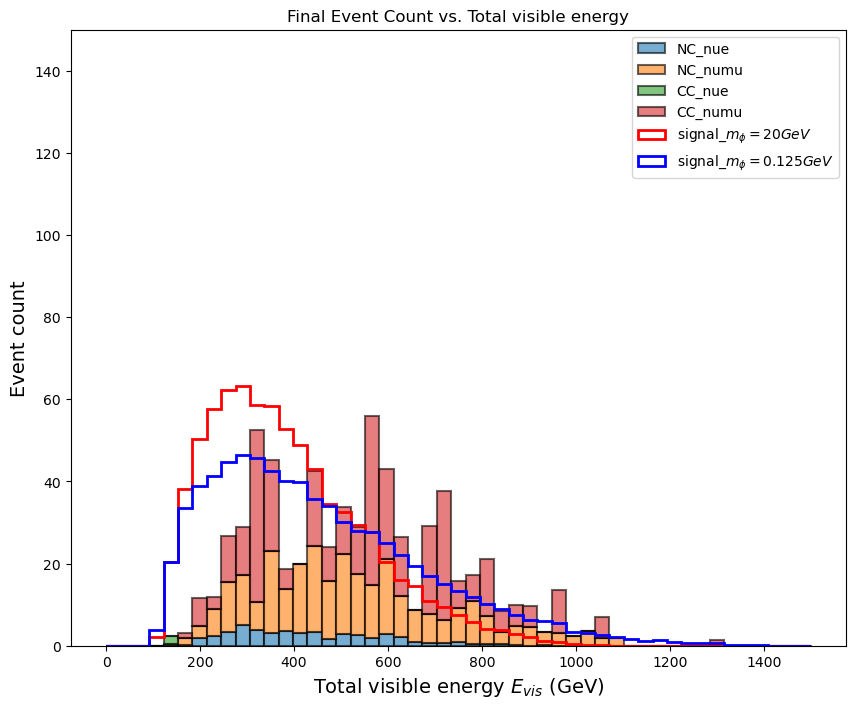

CC_nue events after cut: 2.12e+00
CC_numu events after cut: 1.33e+02
NC_nue events after cut: 3.23e+01
NC_numu events after cut: 1.33e+02
Signal 1 (m_phi = 20 GeV) before cut: 7.81e+02
Signal 2 (m_phi = 0.125 GeV) before cut: 7.40e+02
Background before cut: 6.66e+02
Signal 1 (m_phi = 20 GeV) after cut: 6.01e+02
Signal 2 (m_phi = 0.125 GeV) after cut: 4.77e+02
Background after cut: 3.00e+02
Significance for signal 1 (m_phi = 20 GeV) after cut: 34.71
Significance for signal 2 (m_phi = 0.125 GeV) after cut: 27.55


In [2]:
###Next check for visible energy with EM energy cut plus mu+ threshold,mu- threshold already present 
##Also add CHARM veto 80%
####Plot for visible energy
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

import os
import pandas as pd



def read_energy_and_cross_section(directory, prefix, suffix):
    energies = []
    cross_sections = []
    
    
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            filepath = os.path.join(directory, filename)
            
            
            if os.path.isfile(filepath):
                try:
                    
                    df = pd.read_csv(filepath)
                    
                    
                    if 'Energy' in df.columns and 'Cross_section_pb' in df.columns:
                        
                        energy = df['Energy'].iloc[0]
                        cross_section = df['Cross_section_pb'].iloc[0]

                       
                        if prefix == 'hadron_events_mass_':
                            cross_section *= 1 ##Earlier was considering coupling to scale the cross section

                        
                        energies.append(energy)
                        cross_sections.append(cross_section)
                    else:
                        print(f"Missing required columns in file: {filepath}")
                except Exception as e:
                    print(f"Error reading file {filepath}: {e}")
            else:
                print(f"File not found: {filepath}")
    
    return energies, cross_sections



def parse_events_from_df(df):
    events = []
    event = []

    for index, row in df.iterrows():
        if pd.isnull(row['pid']):
            if event:
                events.append(event)
                event = []
            continue

        pid = row['pid']
        momentum_str = row['momentum']
        parent_pids_str = row['parent_pids']

        px, py, pz, e = eval(momentum_str)
        mother1_pid, mother2_pid = eval(parent_pids_str)

        event.append((pid, px, py, pz, e, mother1_pid, mother2_pid))

    if event:
        events.append(event)

    return events




# def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
#     #EM_energy_sums = defaultdict(lambda: defaultdict(list))
#     visible_energy_sums = defaultdict(lambda: defaultdict(list)) 
#     for filename in os.listdir(directory):
#         if filename.startswith(prefix) and filename.endswith(suffix):
#             parts = filename[len(prefix):-len(suffix)].split('_')
#             energy = float(parts[-1])  

#             filepath = os.path.join(directory, filename)
            

           
#             df = pd.read_csv(filepath)

            
#             events = parse_events_from_df(df)
#             pid_inv = [12, -12, 14, -14, 16, -16,39]
#             excluded_pids = [11, 22, -11]
                        
#             for event in events:                    
#                 muon_plus_found = False
#                 muon_minus_high_energy_found = False
#                 EM_energy_sum = 0
#                 visible_energy_sum=0
#                 charm_meson_parent_found = False

#                 for pid, px, py, pz, e, parent_pid, _ in event:
#                     if pid==-13 and parent_pid in [411, -411, 421, -421, 431, -431,4,4122,-4122,15,-15,521,-521,511,-511,531,-531,443,-443,5122,-5122,4232,-4232,4112,-4112,5232,-5232]:  
#                         charm_meson_parent_found = True
                        
                    
#                     elif pid == -13 and e > muon_plus_threshold:  
#                         muon_plus_found = True
#                         visible_energy_sum += e

#                     elif pid == 13 and e > 10:  
#                          muon_minus_high_energy_found = True
                        
#                     elif pid in excluded_pids:  
#                          EM_energy_sum += e  
                        
#                     elif pid not in pid_inv:  
#                          visible_energy_sum += e 
                            
#                 if muon_plus_found:
#                     if EM_energy_sum > 200:
#                         continue

                
#                 if muon_plus_found and not muon_minus_high_energy_found: 
#                     if charm_meson_parent_found:
                    
#                         weight_modifier = 1 
#                     else:
#                         weight_modifier = 1
    
#                     visible_energy_sums[energy]['visible_energy_sum'].append((visible_energy_sum, weight_modifier))


#     return visible_energy_sums


def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
    # Dictionary to store sums of visible energy for each energy value
    visible_energy_sums = defaultdict(lambda: defaultdict(list))
    
    # Define the invariant and excluded particle IDs
    pid_inv = [12, -12, 14, -14, 16, -16, 39]  # Neutrinos and other invisible particles
    excluded_pids = [11, 22, -11]  # Electron, positron, photon
    
    # Define the list of PIDs considered as charm meson parents
    charm_meson_pids = [411, -411, 421, -421, 431, -431, 4, 4122, -4122, 
                        15, -15, 521, -521, 511, -511, 531, -531, 443, -443, 
                        5122, -5122, 4232, -4232, 4112, -4112, 5232, -5232]

    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            # Extract the energy from the filename
            parts = filename[len(prefix):-len(suffix)].split('_')
            energy = float(parts[-1])  # Extract the energy value from the filename
            
            # Read the CSV file into a DataFrame
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            
            # Parse events from DataFrame
            events = parse_events_from_df(df)
            
            for event in events:                    
                muon_plus_found = False
                muon_minus_high_energy_found = False
                EM_energy_sum = 0
                visible_energy_sum = 0
                muon_plus_parent_pid = None  # Track the parent PID of muon+

                # Loop through particles in the event
                for pid, px, py, pz, e, parent_pid, _ in event:
                    if pid == -13 and e > muon_plus_threshold:  # Muon+ found
                        muon_plus_found = True
                        visible_energy_sum += e
                        muon_plus_parent_pid = parent_pid  # Record the parent PID of muon+
                    
                    elif pid == 13 and e > 10:  # Muon- with high energy found
                        muon_minus_high_energy_found = True
                        
                    elif pid in excluded_pids:  # Sum electromagnetic energy
                        EM_energy_sum += e
                        
                    elif pid not in pid_inv:  # Sum visible energy for all other particles
                        visible_energy_sum += e
                
                # Apply veto for high electromagnetic energy sum (> 200)
                if muon_plus_found:
                    if EM_energy_sum > 200:
                        continue

                # Apply cuts if muon+ is found and no high-energy muon- is present
                if muon_plus_found and not muon_minus_high_energy_found:
                    if muon_plus_parent_pid in charm_meson_pids:
                        weight_modifier = 1 / 5  # Apply a weight modifier for charm meson parents
                    else:
                        weight_modifier = 1  # Apply a default weight for non-charm meson parents
                    
                    # Append the visible energy and weight modifier to the dictionary
                    visible_energy_sums[energy]['visible_energy_sum'].append((visible_energy_sum, weight_modifier))

    return visible_energy_sums

def apply_cut(visible_energy_sums, weights, visible_cut):
    
    visible_energy_sums = np.array(visible_energy_sums)
    pass_cut = visible_energy_sums < visible_cut
    return np.array(weights)[pass_cut]

def calculate_significance(S, B):
    
    if B == 0:
        return np.inf 
    return S / np.sqrt(B)

def main():
    datasets = {
        'NC_nue': ('angle_NC_nue', 'events_', '_GeV.csv'),
        'CC_nue': ('angle_CC_nue', 'events_', '_GeV.csv'),
        'CC_numu': ('angle_CC_numu', 'events_', '_GeV.csv'),
        'NC_numu': ('angle_NC_numu', 'events_', '_GeV.csv'),
        'signal_1': ('Hadron_events_output', 'hadron_events_mass_', '.csv'),
        'signal_2': ('Hadron_events_output/mass = 0.125', 'hadron_events_mass_', '.csv')
    }

    scaling_factor = 1.9060455065868266e-11
    ###Flux of incoming neutrinos
    file1 = "MC_-14_3TeV_with_cut_with_z.txt"
    column_names_df1 = ["x", "y","z"]
    df1 = pd.read_csv(file1, delim_whitespace=True, names=column_names_df1)
    energy_events = df1["x"]
    events_per_year = df1["y"] * 3 * 10**7
    events_per_year_nue = df1["z"] * 3 * 10**7

    all_final_events = defaultdict(lambda: defaultdict(list))

    muon_plus_thresholds = [100]
    colors = {
        'NC_nue': ['yellow'],
        'CC_nue': ['purple'],
        'CC_numu': ['orange'],
        'NC_numu': ['green'],
        'signal_1': ['red'],
        'signal_2': ['blue']
    }

    plt.figure(figsize=(10, 8))

    bins = np.linspace(0,1500, 50)  

    stacked_data = defaultdict(list)
    signal_1_energy_sums = []
    signal_1_weights = []
    signal_2_energy_sums = []
    signal_2_weights = []

    total_signal_1_events = 0
    total_signal_2_events = 0

    for dataset_name, (directory, prefix, suffix) in datasets.items():
        print(f"Processing dataset: {dataset_name}")

        energies, cross_sections = read_energy_and_cross_section(directory, prefix, suffix)
        cross_section_dict = dict(zip(energies, cross_sections))

        for threshold, color in zip(muon_plus_thresholds, colors[dataset_name]):
            condition_label = f'muon+_gt_{threshold}GeV'
            
            group_counts_with_veto = count_muon_events(directory, muon_plus_threshold=threshold, prefix=prefix, suffix=suffix)

            for energy, energy_data in group_counts_with_veto.items():
                if dataset_name in ['CC_nue', 'NC_nue']:
                    events_rate = events_per_year_nue[energy_events == energy].values
                else:
                    events_rate = events_per_year[energy_events == energy].values
                
                cross_section = cross_section_dict.get(energy, None)

                for visible_energy_sum, weight_modifier in energy_data['visible_energy_sum']:
                    
                        
                    if dataset_name in ['CC_nue', 'NC_nue']:
                        if energy > 800:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10*10**6))
                        else:
                            scaled_event_rate = events_rate[0] * cross_section * scaling_factor*weight_modifier / 10**6
                            
                    elif dataset_name == 'NC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.55**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**6))
                    
                    elif dataset_name == 'CC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.3**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.3**6))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**6))
                    elif dataset_name == 'signal_1':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor*weight_modifier) / 10**4
                        total_signal_1_events += scaled_event_rate
                    elif dataset_name == 'signal_2':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor*weight_modifier) / 10**4
                        total_signal_2_events += scaled_event_rate

                    


                    all_final_events[dataset_name][condition_label].append((visible_energy_sum, scaled_event_rate))

            energy_sums = []
            weights = []

            if condition_label in all_final_events[dataset_name]:
                for visible_energy_sum, weight in all_final_events[dataset_name][condition_label]:
                    energy_sums.append(visible_energy_sum)
                    weights.append(weight)

                if dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
                    stacked_data[dataset_name].append((energy_sums, weights))
                elif dataset_name == 'signal_1':
                     signal_1_energy_sums.extend(energy_sums)
                     signal_1_weights.extend(weights)
                elif dataset_name == 'signal_2':
                     signal_2_energy_sums.extend(energy_sums)
                     signal_2_weights.extend(weights)

  

                 
 
    if total_signal_1_events > 0:
        scaling_factor_signal_1 = 781 / total_signal_1_events
        #print(scaling_factor_signal_1)
        signal_1_weights = [w * scaling_factor_signal_1 for w in signal_1_weights]

    if total_signal_2_events > 0:
        scaling_factor_signal_2 = 740/ total_signal_2_events
        #print(scaling_factor_signal_2)
        signal_2_weights = [w * scaling_factor_signal_2 for w in signal_2_weights]


    
    ratio_signal_1_to_background = []
    ratio_signal_2_to_background = []

    
    background_muon_energies = []
    background_weights = []
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        for muon_energies, weights in stacked_data[dataset_name]:
            background_muon_energies.extend(muon_energies)
            background_weights.extend(weights)
    
    background_total_weights, _ = np.histogram(background_muon_energies, 
                                               bins=bins, 
                                               weights=background_weights)
    
    signal_1_hist_weights, _ = np.histogram(signal_1_energy_sums, bins=bins, weights=signal_1_weights)
    
    signal_2_hist_weights, _ = np.histogram(signal_2_energy_sums, bins=bins, weights=signal_2_weights)
    
    
    background_event_counts_before_cut = {}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        
        total_weight_before_cut = sum([np.sum(weights) for _, weights in stacked_data[dataset_name]])
        
        background_event_counts_before_cut[dataset_name] = total_weight_before_cut
        
        print(f"{dataset_name} events before cut: {total_weight_before_cut:.2e}")
        
    for bkg, sig1, sig2 in zip(background_total_weights, signal_1_hist_weights, signal_2_hist_weights):
        
        ratio_signal_1_to_background.append(sig1 / bkg if bkg > 0 else 0)
        
        ratio_signal_2_to_background.append(sig2 / bkg if bkg > 0 else 0)

    plt.hist([energy_sums for energy_sums, _ in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             bins=bins,
             weights=[weights for _, weights in stacked_data['NC_nue'] + stacked_data['NC_numu']+ stacked_data['CC_nue']+ stacked_data['CC_numu']],
             histtype="barstacked", alpha=0.6, stacked=True, edgecolor='black', linewidth=1.5,
             label=['NC_nue','NC_numu', 'CC_nue','CC_numu'])#, color=['yellow','green', 'purple','orange'])

    plt.hist(signal_1_energy_sums, bins=bins, weights=signal_1_weights, histtype="step", color='red', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=20GeV$')
    plt.hist(signal_2_energy_sums, bins=bins, weights=signal_2_weights, histtype="step", color='blue', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=0.125GeV$')

    # Plot ratio of signal to BG
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     plt.plot(bin_centers, ratio_signal_1_to_background, 'r--',marker='.', label=r'Ratio to BG: $m_{\phi}=20GeV$')
#     plt.plot(bin_centers, ratio_signal_2_to_background, 'b--',marker='.', label=r'Ratio to BG: $m_{\phi}=0.125GeV$')

    plt.xlabel(r'Total visible energy $E_{vis}$ (GeV)', fontsize=14)
    plt.ylabel('Event count', fontsize=14)
    plt.title(r'Final Event Count vs. Total visible energy')
    #plt.yscale('log')
    plt.ylim(0, 150)
    ax = plt.gca()  # Get current axes
    #formatter = mticker.ScalarFormatter(useMathText=True)
    #formatter.set_powerlimits((6, 7))  
    #ax.yaxis.set_major_formatter(formatter)
    plt.legend(loc='upper right')
    
    plt.show()
    
    visible_cut_value = 500 

    signal_1_weights_after_cut = apply_cut(signal_1_energy_sums, signal_1_weights, visible_cut_value)
    signal_2_weights_after_cut = apply_cut(signal_2_energy_sums, signal_2_weights, visible_cut_value)
    background_weights_after_cut = apply_cut(background_muon_energies, background_weights, visible_cut_value)
    background_event_counts_after_cut={}
    for dataset_name in ['CC_nue', 'CC_numu', 'NC_nue', 'NC_numu']:
        pt_sums_after_cut = []
        weights_after_cut = []
        for pt_sums, weights in stacked_data[dataset_name]:
            filtered_weights = apply_cut(pt_sums, weights, visible_cut_value)
            pt_sums_after_cut.extend(pt_sums)
            weights_after_cut.extend(filtered_weights)
    
        total_weight_after_cut = np.sum(weights_after_cut)
        background_event_counts_after_cut[dataset_name] = total_weight_after_cut
        print(f"{dataset_name} events after cut: {total_weight_after_cut:.2e}")
    
    S_signal_1 = np.sum(signal_1_weights_after_cut)
    S_signal_2 = np.sum(signal_2_weights_after_cut)
    B_background = np.sum(background_weights_after_cut)
    total_signal_1_before_cut = np.sum(signal_1_weights)
    total_signal_2_before_cut = np.sum(signal_2_weights)
    total_background_before_cut = np.sum(background_weights)


    


    
    significance_signal_1 = calculate_significance(S_signal_1, B_background)
    significance_signal_2 = calculate_significance(S_signal_2, B_background)
    print(f"Signal 1 (m_phi = 20 GeV) before cut: {total_signal_1_before_cut:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) before cut: {total_signal_2_before_cut:.2e}")
    print(f"Background before cut: {total_background_before_cut:.2e}")
    print(f"Signal 1 (m_phi = 20 GeV) after cut: {S_signal_1:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) after cut: {S_signal_2:.2e}")
    print(f"Background after cut: {B_background:.2e}")
    print(f"Significance for signal 1 (m_phi = 20 GeV) after cut: {significance_signal_1:.2f}")
    print(f"Significance for signal 2 (m_phi = 0.125 GeV) after cut: {significance_signal_2:.2f}")
    


if __name__ == '__main__':
    main()


Next after considering all the other cuts upto CHARM veto we can now put other cuts such as missing pt 

Processing dataset: NC_nue
Processing dataset: CC_nue
Processing dataset: CC_numu
Processing dataset: NC_numu
Processing dataset: signal_1
Processing dataset: signal_2
CC_nue events before cut: 2.12e+00
NC_numu events before cut: 3.56e+00
NC_nue events before cut: 6.64e-01
CC_numu events before cut: 0.00e+00


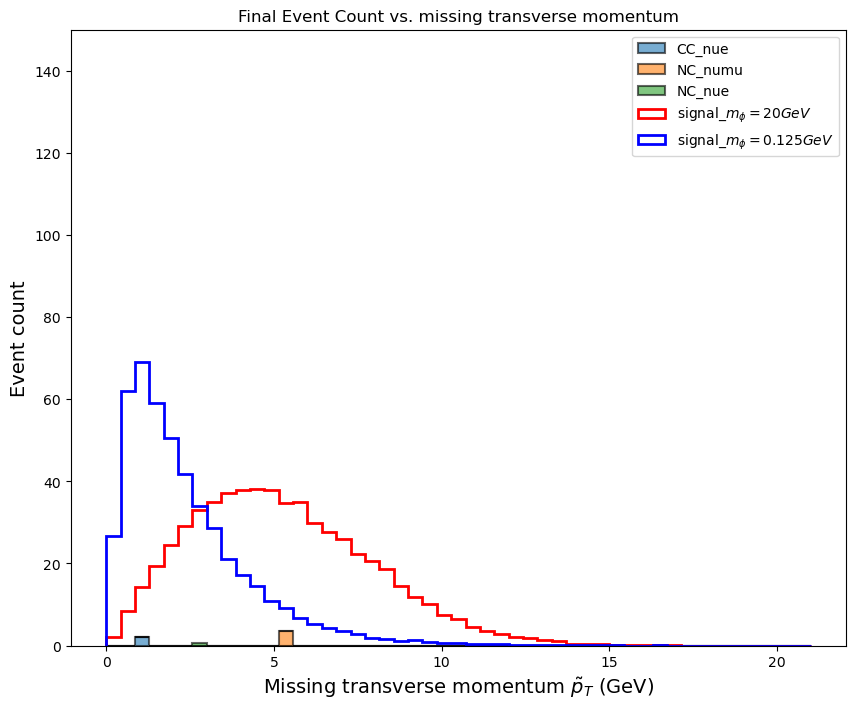

NC_nue events after cut: 0.00e+00
NC_numu events after cut: 0.00e+00
CC_nue events after cut: 0.00e+00
CC_numu events after cut: 0.00e+00
0.0
Signal 1 (m_phi = 20 GeV) before cut: 6.01e+02
Signal 2 (m_phi = 0.125 GeV) before cut: 4.77e+02
Background before cut: 6.34e+00
Signal 1 (m_phi = 20 GeV) after cut: 2.14e+02
Signal 2 (m_phi = 0.125 GeV) after cut: 2.54e+01
Background after cut: 0.00e+00
Significance for signal 1 (m_phi = 20 GeV) after cut: inf
Significance for signal 2 (m_phi = 0.125 GeV) after cut: inf


In [3]:
###After already putting EM energy cut, mu+ threshold and visible energy cut on missing transverse momentum
#100%charm veto
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

import os
import pandas as pd



def read_energy_and_cross_section(directory, prefix, suffix):
    energies = []
    cross_sections = []
    
    
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            filepath = os.path.join(directory, filename)
            
            
            if os.path.isfile(filepath):
                try:
                    
                    df = pd.read_csv(filepath)
                    
                    
                    if 'Energy' in df.columns and 'Cross_section_pb' in df.columns:
                        
                        energy = df['Energy'].iloc[0]
                        cross_section = df['Cross_section_pb'].iloc[0]

                       
                        if prefix == 'hadron_events_mass_':
                            cross_section *= 1 ##Earlier was considering coupling to scale the cross section

                        
                        energies.append(energy)
                        cross_sections.append(cross_section)
                    else:
                        print(f"Missing required columns in file: {filepath}")
                except Exception as e:
                    print(f"Error reading file {filepath}: {e}")
            else:
                print(f"File not found: {filepath}")
    
    return energies, cross_sections



def parse_events_from_df(df):
    events = []
    event = []

    for index, row in df.iterrows():
        if pd.isnull(row['pid']):
            if event:
                events.append(event)
                event = []
            continue

        pid = row['pid']
        momentum_str = row['momentum']
        parent_pids_str = row['parent_pids']

        px, py, pz, e = eval(momentum_str)
        mother1_pid, mother2_pid = eval(parent_pids_str)

        event.append((pid, px, py, pz, e, mother1_pid, mother2_pid))

    if event:
        events.append(event)

    return events






def transverse_momentum(px, py):
    return np.sqrt(px**2 + py**2)




def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
    muon_counts = defaultdict(lambda: defaultdict(int))  
    pt_sums = defaultdict(lambda: defaultdict(list)) 
    surviving_parent_pids = defaultdict(list)  

    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            parts = filename[len(prefix):-len(suffix)].split('_')
            energy = float(parts[-1])  

            filepath = os.path.join(directory, filename)
            

           
            df = pd.read_csv(filepath)

            
            events = parse_events_from_df(df)
            pid_inv = [12, -12, 14, -14, 16, -16,39]
            #excluded_pidss = [-211,211,2112,-2112,-321,321,130,2212,-2212]
            
            for event in events:
                muon_plus_found = False  
                muon_minus_high_energy_found = False
                total_px = 0  
                total_py = 0 
                total_electron_photon_energy = 0  
                charm_meson_parent_found = False
                visible_energy_sum = 0
                excluded_pids = [11, 22, -11]
                pid_inv = [12, -12, 14, -14, 16, -16,39]
                for pid, px, py, pz, e, parent_pid, _ in event:
                    if pid == -13 and parent_pid in [411, -411, 421, -421, 431, -431,4,4122,-4122,15,-15,521,-521,511,-511,531,-531,443,-443,5122,-5122,4232,-4232,4112,-4112,5232,-5232]:  
                        charm_meson_parent_found = True
                        

                    elif pid == -13 and e > muon_plus_threshold:  
                        muon_plus_found = True
                        total_px += px  
                        total_py += py  
                        visible_energy_sum += e  
                    elif pid == 13 and e > 10:  
                        muon_minus_high_energy_found = True
                    elif pid in excluded_pids:  
                        total_electron_photon_energy += e
                    elif pid not in pid_inv:  
                        total_px += px
                        total_py += py
                        visible_energy_sum += e

                if charm_meson_parent_found:
                    continue

                if muon_plus_found:
                    if total_electron_photon_energy > 200:
                        continue
                    if visible_energy_sum > 500:
                        continue
                
                
                pt_sum = np.sqrt(total_px**2 + total_py**2)

                
                
                
                
                # Store the sum of transverse momentum for the event if muon+ is found and muon- is not high energy
                if muon_plus_found and not muon_minus_high_energy_found:
                        pt_sums[energy]['pt_sum'].append(pt_sum)

    return pt_sums

  
         




def apply_cut(pt_sums, weights, pt_cut):
    
    pt_sums = np.array(pt_sums)
    pass_cut = pt_sums > pt_cut
    return np.array(weights)[pass_cut]

def calculate_significance(S, B):
    
    if B == 0:
        return np.inf  # Avoid division by zero
    return S / np.sqrt(B)
def main():
    datasets = {
        'NC_nue': ('angle_NC_nue', 'events_', '_GeV.csv'),
        'CC_nue': ('angle_CC_nue', 'events_', '_GeV.csv'),
        'CC_numu': ('angle_CC_numu', 'events_', '_GeV.csv'),
        'NC_numu': ('angle_NC_numu', 'events_', '_GeV.csv'),
        'signal_1': ('Hadron_events_output', 'hadron_events_mass_', '.csv'),
        'signal_2': ('Hadron_events_output/mass = 0.125', 'hadron_events_mass_', '.csv')
    }

    scaling_factor = 1.9060455065868266e-11
    ###Flux of incoming neutrinos
    file1 = "MC_-14_3TeV_with_cut_with_z.txt"
    column_names_df1 = ["x", "y","z"]
    df1 = pd.read_csv(file1, delim_whitespace=True, names=column_names_df1)
    energy_events = df1["x"]
    events_per_year = df1["y"] * 3 * 10**7
    events_per_year_nue = df1["z"] * 3 * 10**7

    all_final_events = defaultdict(lambda: defaultdict(list))

    muon_plus_thresholds = [100]
    colors = {
        'NC_nue': ['yellow'],
        'CC_nue': ['purple'],
        'CC_numu': ['orange'],
        'NC_numu': ['green'],
        'signal_1': ['red'],
        'signal_2': ['blue']
    }

    plt.figure(figsize=(10, 8))

    bins = np.linspace(0,21, 50)  

    stacked_data = defaultdict(list)
    signal_1_pt_sums = []
    signal_1_weights = []
    signal_2_pt_sums = []
    signal_2_weights = []

    total_signal_1_events = 0
    total_signal_2_events = 0

    for dataset_name, (directory, prefix, suffix) in datasets.items():
        print(f"Processing dataset: {dataset_name}")

        energies, cross_sections = read_energy_and_cross_section(directory, prefix, suffix)
        cross_section_dict = dict(zip(energies, cross_sections))

        for threshold, color in zip(muon_plus_thresholds, colors[dataset_name]):
            condition_label = f'muon+_gt_{threshold}GeV'
            
            group_counts_with_veto = count_muon_events(directory, muon_plus_threshold=threshold, prefix=prefix, suffix=suffix)

            for energy, pt_data in group_counts_with_veto.items():
                if dataset_name in ['CC_nue', 'NC_nue']:
                    events_rate = events_per_year_nue[energy_events == energy].values
                else:
                    events_rate = events_per_year[energy_events == energy].values
                
                cross_section = cross_section_dict.get(energy, None)

                for pt_sum in pt_data['pt_sum']:
                    if dataset_name in ['CC_nue', 'NC_nue']:
                        if energy > 800:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10*10**6))
                        else:
                            scaled_event_rate = events_rate[0] * cross_section * scaling_factor / 10**6
                            
                    elif dataset_name == 'NC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.55**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    
                    elif dataset_name == 'CC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10.3**6))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor) / (10**6))
                    elif dataset_name == 'signal_1':
                        scaled_event_rate = events_rate[0] * cross_section * scaling_factor / 10**4
                        total_signal_1_events += scaled_event_rate
                    elif dataset_name == 'signal_2':
                        scaled_event_rate = events_rate[0] * cross_section * scaling_factor / 10**4
                        total_signal_2_events += scaled_event_rate
                    all_final_events[dataset_name][condition_label].append((pt_sum, scaled_event_rate))

            pt_sums = []
            weights = []

            if condition_label in all_final_events[dataset_name]:
                for pt_sum, weight in all_final_events[dataset_name][condition_label]:
                    pt_sums.append(pt_sum)
                    weights.append(weight)

                if dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
                    stacked_data[dataset_name].append((pt_sums, weights))
                elif dataset_name == 'signal_1':
                     signal_1_pt_sums.extend(pt_sums)
                     signal_1_weights.extend(weights)
                elif dataset_name == 'signal_2':
                     signal_2_pt_sums.extend(pt_sums)
                     signal_2_weights.extend(weights)



   

    if total_signal_1_events > 0:
        scaling_factor_signal_1 =601/ total_signal_1_events
        signal_1_weights = [w * scaling_factor_signal_1 for w in signal_1_weights]
    #print(scaling_factor_signal_1)
    if total_signal_2_events > 0:
        scaling_factor_signal_2 =   477 / total_signal_2_events
        signal_2_weights = [w * scaling_factor_signal_2 for w in signal_2_weights]
    #print(scaling_factor_signal_2)
    
    
    ratio_signal_1_to_background = []
    ratio_signal_2_to_background = []

    
    background_muon_energies = []
    background_weights = []
    for dataset_name in ['CC_nue', 'NC_numu','NC_nue','CC_numu']:
        for pt_sums, weights in stacked_data[dataset_name]:
            background_muon_energies.extend(pt_sums)
            background_weights.extend(weights)
    
    background_total_weights, _ = np.histogram(background_muon_energies, 
                                               bins=bins, 
                                               weights=background_weights)
    
    background_event_counts_before_cut = {}
    for dataset_name in ['CC_nue', 'NC_numu','NC_nue','CC_numu']:
        total_weight_before_cut = sum([np.sum(weights) for _, weights in stacked_data[dataset_name]])
        background_event_counts_before_cut[dataset_name] = total_weight_before_cut
        print(f"{dataset_name} events before cut: {total_weight_before_cut:.2e}")
    
    
    
    
    
    signal_1_hist_weights, _ = np.histogram(signal_1_pt_sums, bins=bins, weights=signal_1_weights)
    signal_2_hist_weights, _ = np.histogram(signal_2_pt_sums, bins=bins, weights=signal_2_weights)
    
    for bkg, sig1, sig2 in zip(background_total_weights, signal_1_hist_weights, signal_2_hist_weights):
        ratio_signal_1_to_background.append(sig1 / bkg if bkg > 0 else 0)
        ratio_signal_2_to_background.append(sig2 / bkg if bkg > 0 else 0)

    plt.hist([pt_sums for pt_sums, _ in stacked_data['CC_nue'] + stacked_data['NC_numu']+ stacked_data['NC_nue']+ stacked_data['CC_numu']],
             bins=bins,
             weights=[weights for _, weights in stacked_data['CC_nue'] + stacked_data['NC_numu']+ stacked_data['NC_nue']+ stacked_data['CC_numu']],
             histtype="barstacked", alpha=0.6, stacked=True, edgecolor='black', linewidth=1.5,
             label=['CC_nue','NC_numu', 'NC_nue','CC_numu'])#, color=['yellow','green', 'purple','orange'])

    plt.hist(signal_1_pt_sums, bins=bins, weights=signal_1_weights, histtype="step", color='red', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=20GeV$')
    plt.hist(signal_2_pt_sums, bins=bins, weights=signal_2_weights, histtype="step", color='blue', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=0.125GeV$')

    # Plot the ratio of signal to background
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     plt.plot(bin_centers, ratio_signal_1_to_background, 'r--',marker='.', label=r'Ratio to BG: $m_{\phi}=20GeV$')
#     plt.plot(bin_centers, ratio_signal_2_to_background, 'b--',marker='.', label=r'Ratio to BG: $m_{\phi}=0.125GeV$')

    plt.xlabel(r'Missing transverse momentum $\tilde{p}_T$ (GeV)', fontsize=14)
    plt.ylabel('Event count', fontsize=14)
    plt.title(r'Final Event Count vs. missing transverse momentum')
    #plt.yscale('log')
    plt.ylim(0, 1*150)
    ax = plt.gca()  # Get current axes
    #formatter = mticker.ScalarFormatter(useMathText=True)
    #formatter.set_powerlimits((6, 7))  
    #ax.yaxis.set_major_formatter(formatter)
    plt.legend(loc='upper right')
    
    plt.show()
    
    pt_cut_value = 6 
    
    
    signal_1_weights_after_cut = apply_cut(signal_1_pt_sums, signal_1_weights, pt_cut_value)
    signal_2_weights_after_cut = apply_cut(signal_2_pt_sums, signal_2_weights, pt_cut_value)
    background_weights_after_cut = apply_cut(background_muon_energies, background_weights, pt_cut_value)
    background_event_counts_after_cut = {}
    for dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
        pt_sums_after_cut = []
        weights_after_cut = []
        for pt_sums, weights in stacked_data[dataset_name]:
            filtered_weights = apply_cut(pt_sums, weights, pt_cut_value)
            pt_sums_after_cut.extend(pt_sums)
            weights_after_cut.extend(filtered_weights)
    
        total_weight_after_cut = np.sum(weights_after_cut)
        background_event_counts_after_cut[dataset_name] = total_weight_after_cut
        print(f"{dataset_name} events after cut: {total_weight_after_cut:.2e}")
    
    S_signal_1 = np.sum(signal_1_weights_after_cut)
    S_signal_2 = np.sum(signal_2_weights_after_cut)
    B_background = np.sum(background_weights_after_cut)
    total_signal_1_before_cut = np.sum(signal_1_weights)
    total_signal_2_before_cut = np.sum(signal_2_weights)
    total_background_before_cut = np.sum(background_weights)
    #print(total_background_before_cut)
    

    
    significance_signal_1 = calculate_significance(S_signal_1, B_background)
    significance_signal_2 = calculate_significance(S_signal_2, B_background)
    print(B_background)
    #coupling1=np.sqrt(scaling_factor_signal_1)
    #coupling2=np.sqrt(scaling_factor_signal_2)
    print(f"Signal 1 (m_phi = 20 GeV) before cut: {total_signal_1_before_cut:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) before cut: {total_signal_2_before_cut:.2e}")
    print(f"Background before cut: {total_background_before_cut:.2e}")
    print(f"Signal 1 (m_phi = 20 GeV) after cut: {S_signal_1:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) after cut: {S_signal_2:.2e}")
    print(f"Background after cut: {B_background:.2e}")
    print(f"Significance for signal 1 (m_phi = 20 GeV) after cut: {significance_signal_1:.2f}")
    print(f"Significance for signal 2 (m_phi = 0.125 GeV) after cut: {significance_signal_2:.2f}")
    


if __name__ == '__main__':
    main()



Processing dataset: NC_nue
Processing dataset: CC_nue
Processing dataset: CC_numu
Processing dataset: NC_numu
Processing dataset: signal_1
Processing dataset: signal_2
CC_nue events before cut: 2.12e+00
NC_numu events before cut: 1.33e+02
NC_nue events before cut: 3.23e+01
CC_numu events before cut: 1.33e+02


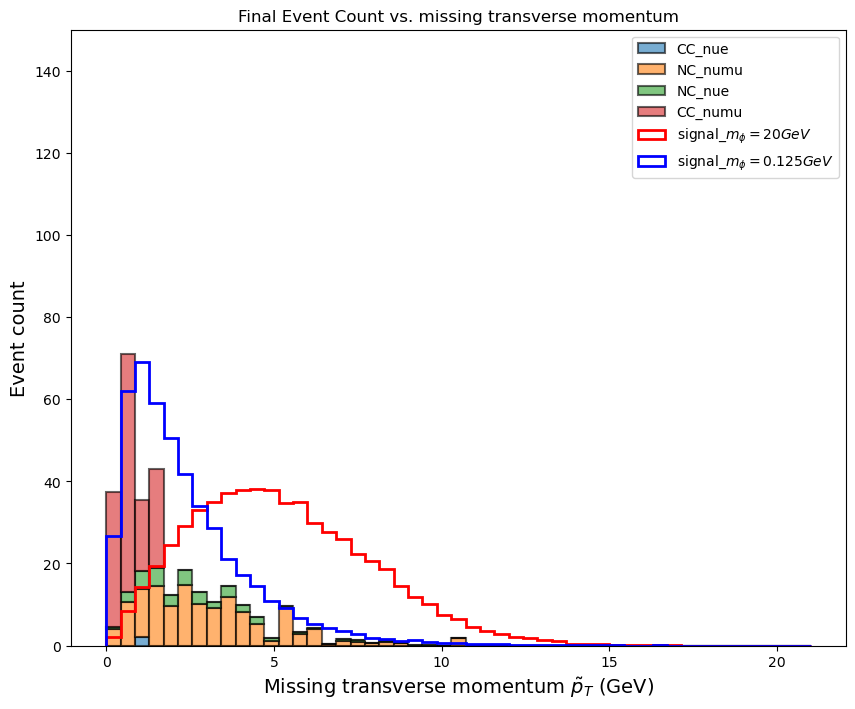

NC_nue events after cut: 2.53e+00
NC_numu events after cut: 1.04e+01
CC_nue events after cut: 0.00e+00
CC_numu events after cut: 0.00e+00
12.897024166946835
Signal 1 (m_phi = 20 GeV) before cut: 6.01e+02
Signal 2 (m_phi = 0.125 GeV) before cut: 4.77e+02
Background before cut: 3.00e+02
Signal 1 (m_phi = 20 GeV) after cut: 2.14e+02
Signal 2 (m_phi = 0.125 GeV) after cut: 2.54e+01
Background after cut: 1.29e+01
Significance for signal 1 (m_phi = 20 GeV) after cut: 59.68
Significance for signal 2 (m_phi = 0.125 GeV) after cut: 7.08


In [4]:
###After already putting EM energy cut, mu+ threshold and visible energy cut on missing transverse momentum
##For 80%CHARM veto
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

import os
import pandas as pd



def read_energy_and_cross_section(directory, prefix, suffix):
    energies = []
    cross_sections = []
    
    
    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            filepath = os.path.join(directory, filename)
            
            
            if os.path.isfile(filepath):
                try:
                    
                    df = pd.read_csv(filepath)
                    
                    
                    if 'Energy' in df.columns and 'Cross_section_pb' in df.columns:
                        
                        energy = df['Energy'].iloc[0]
                        cross_section = df['Cross_section_pb'].iloc[0]

                       
                        if prefix == 'hadron_events_mass_':
                            cross_section *= 1 ##Earlier was considering coupling to scale the cross section

                        
                        energies.append(energy)
                        cross_sections.append(cross_section)
                    else:
                        print(f"Missing required columns in file: {filepath}")
                except Exception as e:
                    print(f"Error reading file {filepath}: {e}")
            else:
                print(f"File not found: {filepath}")
    
    return energies, cross_sections



def parse_events_from_df(df):
    events = []
    event = []

    for index, row in df.iterrows():
        if pd.isnull(row['pid']):
            if event:
                events.append(event)
                event = []
            continue

        pid = row['pid']
        momentum_str = row['momentum']
        parent_pids_str = row['parent_pids']

        px, py, pz, e = eval(momentum_str)
        mother1_pid, mother2_pid = eval(parent_pids_str)

        event.append((pid, px, py, pz, e, mother1_pid, mother2_pid))

    if event:
        events.append(event)

    return events






def transverse_momentum(px, py):
    return np.sqrt(px**2 + py**2)




def count_muon_events(directory, muon_plus_threshold, prefix, suffix):
    muon_counts = defaultdict(lambda: defaultdict(int))  
    pt_sums = defaultdict(lambda: defaultdict(list)) 
    surviving_parent_pids = defaultdict(list)  

    for filename in os.listdir(directory):
        if filename.startswith(prefix) and filename.endswith(suffix):
            parts = filename[len(prefix):-len(suffix)].split('_')
            energy = float(parts[-1])  

            filepath = os.path.join(directory, filename)
            

           
            df = pd.read_csv(filepath)

            
            events = parse_events_from_df(df)
            pid_inv = [12, -12, 14, -14, 16, -16,39]
            #excluded_pidss = [-211,211,2112,-2112,-321,321,130,2212,-2212]
            charm_meson_pids = [411, -411, 421, -421, 431, -431, 4, 4122, -4122, 
                        15, -15, 521, -521, 511, -511, 531, -531, 443, -443, 
                        5122, -5122, 4232, -4232, 4112, -4112, 5232, -5232]
            excluded_pids = [11, 22, -11]
            for event in events:
                muon_plus_found = False  
                muon_minus_high_energy_found = False
                total_px = 0  
                total_py = 0 
                total_electron_photon_energy = 0  
                #charm_meson_parent_found = False
                muon_plus_parent_pid=None
                visible_energy_sum = 0
                
                #pid_inv = [12, -12, 14, -14, 16, -16,39]
                for pid, px, py, pz, e, parent_pid, _ in event:
                    if pid == -13 and e > muon_plus_threshold:  
                        muon_plus_found = True
                        visible_energy_sum += e
                        muon_plus_parent_pid = parent_pid
                        total_px += px  
                        total_py += py 

                      
                    elif pid == 13 and e > 10:  
                        muon_minus_high_energy_found = True
                    elif pid in excluded_pids:  
                        total_electron_photon_energy += e
                    elif pid not in pid_inv:  
                        total_px += px
                        total_py += py
                        visible_energy_sum += e


                if muon_plus_found:
                    if total_electron_photon_energy > 200:
                        continue
                    if visible_energy_sum > 500:
                        continue
                
                
                pt_sum = np.sqrt(total_px**2 + total_py**2)

                
                
                
                
                # Store the sum of transverse momentum for the event if muon+ is found and muon- is not high energy
                if muon_plus_found and not muon_minus_high_energy_found:
                    if muon_plus_parent_pid in charm_meson_pids:
                        weight_modifier = 1 / 5  # Apply a weight modifier for charm meson parents
                    else:
                        weight_modifier = 1  # Apply a default weight for non-charm meson parents
                    
                    pt_sums[energy]['pt_sum'].append((pt_sum, weight_modifier))

    return pt_sums






def apply_cut(pt_sums, weights, pt_cut):
    
    pt_sums = np.array(pt_sums)
    pass_cut = pt_sums > pt_cut
    return np.array(weights)[pass_cut]

def calculate_significance(S, B):
    
    if B == 0:
        return np.inf  # Avoid division by zero
    return S / np.sqrt(B)
def main():
    datasets = {
        'NC_nue': ('angle_NC_nue', 'events_', '_GeV.csv'),
        'CC_nue': ('angle_CC_nue', 'events_', '_GeV.csv'),
        'CC_numu': ('angle_CC_numu', 'events_', '_GeV.csv'),
        'NC_numu': ('angle_NC_numu', 'events_', '_GeV.csv'),
        'signal_1': ('Hadron_events_output', 'hadron_events_mass_', '.csv'),
        'signal_2': ('Hadron_events_output/mass = 0.125', 'hadron_events_mass_', '.csv')
    }

    scaling_factor = 1.9060455065868266e-11
    ###Flux of incoming neutrinos
    file1 = "MC_-14_3TeV_with_cut_with_z.txt"
    column_names_df1 = ["x", "y","z"]
    df1 = pd.read_csv(file1, delim_whitespace=True, names=column_names_df1)
    energy_events = df1["x"]
    events_per_year = df1["y"] * 3 * 10**7
    events_per_year_nue = df1["z"] * 3 * 10**7

    all_final_events = defaultdict(lambda: defaultdict(list))

    muon_plus_thresholds = [100]
    colors = {
        'NC_nue': ['yellow'],
        'CC_nue': ['purple'],
        'CC_numu': ['orange'],
        'NC_numu': ['green'],
        'signal_1': ['red'],
        'signal_2': ['blue']
    }

    plt.figure(figsize=(10, 8))

    bins = np.linspace(0,21, 50)  

    stacked_data = defaultdict(list)
    signal_1_pt_sums = []
    signal_1_weights = []
    signal_2_pt_sums = []
    signal_2_weights = []

    total_signal_1_events = 0
    total_signal_2_events = 0

    for dataset_name, (directory, prefix, suffix) in datasets.items():
        print(f"Processing dataset: {dataset_name}")

        energies, cross_sections = read_energy_and_cross_section(directory, prefix, suffix)
        cross_section_dict = dict(zip(energies, cross_sections))

        for threshold, color in zip(muon_plus_thresholds, colors[dataset_name]):
            condition_label = f'muon+_gt_{threshold}GeV'
            
            group_counts_with_veto = count_muon_events(directory, muon_plus_threshold=threshold, prefix=prefix, suffix=suffix)

            for energy, pt_data in group_counts_with_veto.items():
                if dataset_name in ['CC_nue', 'NC_nue']:
                    events_rate = events_per_year_nue[energy_events == energy].values
                else:
                    events_rate = events_per_year[energy_events == energy].values
                
                cross_section = cross_section_dict.get(energy, None)

                for pt_sum,weight_modifier in pt_data['pt_sum']:
                    if dataset_name in ['CC_nue', 'NC_nue']:
                        if energy > 800:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10*10**6))
                        else:
                            scaled_event_rate = (events_rate[0] * cross_section * scaling_factor*weight_modifier) / 10**6
                            
                    elif dataset_name == 'NC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.55**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**6))
                    
                    elif dataset_name == 'CC_numu':
                        if energy == 1421.909302:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.3**6))
                        elif energy == 1129.462706:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10.3**6))
                        
                        elif energy == 897.164117:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**7))
                        else:
                            scaled_event_rate = ((events_rate[0] * cross_section * scaling_factor*weight_modifier) / (10**6))
                    elif dataset_name == 'signal_1':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor*weight_modifier) / 10**4
                        total_signal_1_events += scaled_event_rate
                    elif dataset_name == 'signal_2':
                        scaled_event_rate = (events_rate[0] * cross_section * scaling_factor*weight_modifier) / 10**4
                        total_signal_2_events += scaled_event_rate
                    all_final_events[dataset_name][condition_label].append((pt_sum, scaled_event_rate))

            pt_sums = []
            weights = []

            if condition_label in all_final_events[dataset_name]:
                for pt_sum, weight in all_final_events[dataset_name][condition_label]:
                    pt_sums.append(pt_sum)
                    weights.append(weight)

                if dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
                    stacked_data[dataset_name].append((pt_sums, weights))
                elif dataset_name == 'signal_1':
                     signal_1_pt_sums.extend(pt_sums)
                     signal_1_weights.extend(weights)
                elif dataset_name == 'signal_2':
                     signal_2_pt_sums.extend(pt_sums)
                     signal_2_weights.extend(weights)



   

    if total_signal_1_events > 0:
        scaling_factor_signal_1 =601/ total_signal_1_events
        signal_1_weights = [w * scaling_factor_signal_1 for w in signal_1_weights]
    #print(scaling_factor_signal_1)
    if total_signal_2_events > 0:
        scaling_factor_signal_2 =   477 / total_signal_2_events
        signal_2_weights = [w * scaling_factor_signal_2 for w in signal_2_weights]
    #print(scaling_factor_signal_2)
    
    
    ratio_signal_1_to_background = []
    ratio_signal_2_to_background = []

    
    background_muon_energies = []
    background_weights = []
    for dataset_name in ['CC_nue', 'NC_numu','NC_nue','CC_numu']:
        for pt_sums, weights in stacked_data[dataset_name]:
            background_muon_energies.extend(pt_sums)
            background_weights.extend(weights)
    
    background_total_weights, _ = np.histogram(background_muon_energies, 
                                               bins=bins, 
                                               weights=background_weights)
    
    background_event_counts_before_cut = {}
    for dataset_name in ['CC_nue', 'NC_numu','NC_nue','CC_numu']:
        total_weight_before_cut = sum([np.sum(weights) for _, weights in stacked_data[dataset_name]])
        background_event_counts_before_cut[dataset_name] = total_weight_before_cut
        print(f"{dataset_name} events before cut: {total_weight_before_cut:.2e}")
    
    
    
    
    
    signal_1_hist_weights, _ = np.histogram(signal_1_pt_sums, bins=bins, weights=signal_1_weights)
    signal_2_hist_weights, _ = np.histogram(signal_2_pt_sums, bins=bins, weights=signal_2_weights)
    
    for bkg, sig1, sig2 in zip(background_total_weights, signal_1_hist_weights, signal_2_hist_weights):
        ratio_signal_1_to_background.append(sig1 / bkg if bkg > 0 else 0)
        ratio_signal_2_to_background.append(sig2 / bkg if bkg > 0 else 0)

    plt.hist([pt_sums for pt_sums, _ in stacked_data['CC_nue'] + stacked_data['NC_numu']+ stacked_data['NC_nue']+ stacked_data['CC_numu']],
             bins=bins,
             weights=[weights for _, weights in stacked_data['CC_nue'] + stacked_data['NC_numu']+ stacked_data['NC_nue']+ stacked_data['CC_numu']],
             histtype="barstacked", alpha=0.6, stacked=True, edgecolor='black', linewidth=1.5,
             label=['CC_nue','NC_numu', 'NC_nue','CC_numu'])#, color=['yellow','green', 'purple','orange'])

    plt.hist(signal_1_pt_sums, bins=bins, weights=signal_1_weights, histtype="step", color='red', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=20GeV$')
    plt.hist(signal_2_pt_sums, bins=bins, weights=signal_2_weights, histtype="step", color='blue', linestyle='solid', linewidth=2, label=r'signal_$m_{\phi}=0.125GeV$')

    # Plot the ratio of signal to background
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     plt.plot(bin_centers, ratio_signal_1_to_background, 'r--',marker='.', label=r'Ratio to BG: $m_{\phi}=20GeV$')
#     plt.plot(bin_centers, ratio_signal_2_to_background, 'b--',marker='.', label=r'Ratio to BG: $m_{\phi}=0.125GeV$')

    plt.xlabel(r'Missing transverse momentum $\tilde{p}_T$ (GeV)', fontsize=14)
    plt.ylabel('Event count', fontsize=14)
    plt.title(r'Final Event Count vs. missing transverse momentum')
    #plt.yscale('log')
    plt.ylim(0, 1*150)
    ax = plt.gca()  # Get current axes
    #formatter = mticker.ScalarFormatter(useMathText=True)
    #formatter.set_powerlimits((6, 7))  
    #ax.yaxis.set_major_formatter(formatter)
    plt.legend(loc='upper right')
    
    plt.show()
    
    pt_cut_value = 6 
    
    
    signal_1_weights_after_cut = apply_cut(signal_1_pt_sums, signal_1_weights, pt_cut_value)
    signal_2_weights_after_cut = apply_cut(signal_2_pt_sums, signal_2_weights, pt_cut_value)
    background_weights_after_cut = apply_cut(background_muon_energies, background_weights, pt_cut_value)
    background_event_counts_after_cut = {}
    for dataset_name in ['NC_nue', 'NC_numu','CC_nue','CC_numu']:
        pt_sums_after_cut = []
        weights_after_cut = []
        for pt_sums, weights in stacked_data[dataset_name]:
            filtered_weights = apply_cut(pt_sums, weights, pt_cut_value)
            pt_sums_after_cut.extend(pt_sums)
            weights_after_cut.extend(filtered_weights)
    
        total_weight_after_cut = np.sum(weights_after_cut)
        background_event_counts_after_cut[dataset_name] = total_weight_after_cut
        print(f"{dataset_name} events after cut: {total_weight_after_cut:.2e}")
    
    S_signal_1 = np.sum(signal_1_weights_after_cut)
    S_signal_2 = np.sum(signal_2_weights_after_cut)
    B_background = np.sum(background_weights_after_cut)
    total_signal_1_before_cut = np.sum(signal_1_weights)
    total_signal_2_before_cut = np.sum(signal_2_weights)
    total_background_before_cut = np.sum(background_weights)
    #print(total_background_before_cut)
    

    
    significance_signal_1 = calculate_significance(S_signal_1, B_background)
    significance_signal_2 = calculate_significance(S_signal_2, B_background)
    print(B_background)
    #coupling1=np.sqrt(scaling_factor_signal_1)
    #coupling2=np.sqrt(scaling_factor_signal_2)
    print(f"Signal 1 (m_phi = 20 GeV) before cut: {total_signal_1_before_cut:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) before cut: {total_signal_2_before_cut:.2e}")
    print(f"Background before cut: {total_background_before_cut:.2e}")
    print(f"Signal 1 (m_phi = 20 GeV) after cut: {S_signal_1:.2e}")
    print(f"Signal 2 (m_phi = 0.125 GeV) after cut: {S_signal_2:.2e}")
    print(f"Background after cut: {B_background:.2e}")
    print(f"Significance for signal 1 (m_phi = 20 GeV) after cut: {significance_signal_1:.2f}")
    print(f"Significance for signal 2 (m_phi = 0.125 GeV) after cut: {significance_signal_2:.2f}")
    


if __name__ == '__main__':
    main()



In [7]:
import pandas as pd
import numpy as np


data = {
#     'Cuts': [
#         'No cuts', 'mu+ energy>100', 'mu- energy<10', 'EM energy<200 GeV', 'CHARM veto 100%', 'CHARM veto 80%'
#     ],
#     '20GeV_signal_after_cut': [1.00E+03,8.22E+02,8.21E+02,7.81E+02,7.80E+02,7.81E+02],
#     '125MeV_signal_after_cut': [1.00E+03,7.88E+02,7.80E+02,7.40E+02,7.40E+02,7.40E+02],
#     'Background_after_cut': [2.64E+07,9.18E+04,3.86E+03,3.31E+03,7.23E+00,6.66E+02 ]
    
    'Cuts': [
        'CHARM 100% visible','CHARM 100% pt','CHARM 80% visible','CHARM 80% pt'
    ],
    '20GeV_signal_after_cut': [6.01E+02,2.14E+02,6.01E+02,2.14E+02],
    #'125MeV_signal_after_cut': [],
    'Background_after_cut': [6.34E+00,0.00E+00,3.00E+02,1.29E+01 ]
}


df = pd.DataFrame(data)


def find_min_signal(background):
    signal = 4  
    while True:
        s_sqrt_b = signal / np.sqrt(background) if background > 0 else np.inf
        if signal > 3 and s_sqrt_b > 2:
            return signal  
        signal += 1  


min_signals_20GeV = []
min_signals_125MeV = []

for index, row in df.iterrows():
   
    min_signal_20GeV = find_min_signal(row['Background_after_cut']   
    min_signals_20GeV.append({
        'Cut': row['Cuts'],
        'Minimum Signal (20GeV)': min_signal_20GeV
    })

# Output the results
print("Minimum Signal for 20GeV that meets conditions:")
for result in min_signals_20GeV:
    print(result)



Minimum Signal for 20GeV that meets conditions:
{'Cut': 'CHARM 100% visible', 'Minimum Signal (20GeV)': 6}
{'Cut': 'CHARM 100% pt', 'Minimum Signal (20GeV)': 4}
{'Cut': 'CHARM 80% visible', 'Minimum Signal (20GeV)': 35}
{'Cut': 'CHARM 80% pt', 'Minimum Signal (20GeV)': 8}

Minimum Signal for 125MeV that meets conditions:
{'Cut': 'CHARM 100% visible', 'Minimum Signal (125MeV)': 6}
{'Cut': 'CHARM 100% pt', 'Minimum Signal (125MeV)': 4}
{'Cut': 'CHARM 80% visible', 'Minimum Signal (125MeV)': 35}
{'Cut': 'CHARM 80% pt', 'Minimum Signal (125MeV)': 8}


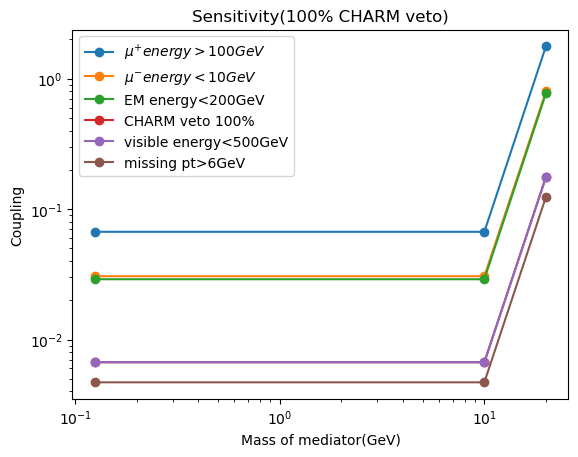

In [19]:
##Plotting sensitivity curve for 100% CHARM veto
import matplotlib.pyplot as plt


mass1, coupling1 = [0.125, 10, 20], [0.067,0.067,1.77]
mass2, coupling2 = [0.125, 10, 20], [0.0306,0.0306,0.8]
mass3, coupling3 = [0.125, 10, 20], [0.029,0.029,0.77]
mass4, coupling4 = [0.125, 10, 20], [0.0067,0.0067,0.176]
mass5, coupling5 = [0.125, 10, 20], [0.0067,0.0067,0.176]
mass6, coupling6 = [0.125, 10, 20], [0.0047,0.0047,0.124]



plt.plot(mass1, coupling1, label=r'$\mu^{+} energy>100GeV$', marker='o')
plt.plot(mass2, coupling2, label=r'$\mu^{-} energy<10GeV$', marker='o')
plt.plot(mass3, coupling3, label=r'EM energy<200GeV', marker='o')
plt.plot(mass4, coupling4, label=r'CHARM veto 100%', marker='o')
plt.plot(mass5, coupling5, label='visible energy<500GeV', marker='o')
plt.plot(mass6, coupling6, label='missing pt>6GeV', marker='o')
plt.xlabel('Mass of mediator(GeV)')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Coupling')
plt.title('Sensitivity(100% CHARM veto)')
plt.legend() 


plt.show()


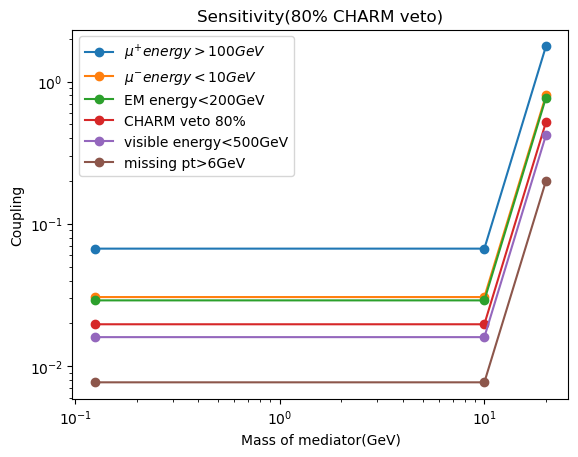

In [20]:
###With 80% CHARM veto



mass1, coupling1 = [0.125, 10, 20], [0.067,0.067,1.77]
mass2, coupling2 = [0.125, 10, 20], [0.0306,0.0306,0.8]
mass3, coupling3 = [0.125, 10, 20], [0.029,0.029,0.77]
mass4, coupling4 = [0.125, 10, 20], [0.0197,0.0197,0.518]
mass5, coupling5 = [0.125, 10, 20], [0.016,0.016,0.42]
mass6, coupling6 = [0.125, 10, 20], [0.0077,0.0077,0.2]



plt.plot(mass1, coupling1, label=r'$\mu^{+} energy>100GeV$', marker='o')
plt.plot(mass2, coupling2, label=r'$\mu^{-} energy<10GeV$', marker='o')
plt.plot(mass3, coupling3, label=r'EM energy<200GeV', marker='o')
plt.plot(mass4, coupling4, label=r'CHARM veto 80%', marker='o')
plt.plot(mass5, coupling5, label='visible energy<500GeV', marker='o')
plt.plot(mass6, coupling6, label='missing pt>6GeV', marker='o')
plt.xlabel('Mass of mediator(GeV)')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Coupling')
plt.title('Sensitivity(80% CHARM veto)')
plt.legend() 


plt.show()
